[0.00981 0.05886 0.10791 0.15696 0.20601 0.25506]
Slope: 21.55+/-0.16 Inter: -0.221+/-0.015
D: 0.04640+/-0.00035 Nm / rad


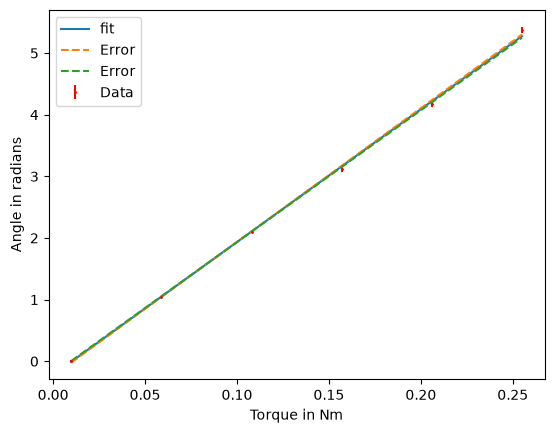

In [29]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt
import scipy
# Aufgabe 1
# Gewicht zu Winkel
# Gewichte in g
Gewichte = (np.array([10,60,110,160,210,260]) / 1000) *2

g = 9.81

Kraft = Gewichte * g
Drehmoment = Kraft * 0.05 # Radius der Scheibe: 5cm
print(Drehmoment)
# Winkel in Grad
# (Unsicherheit 1 Grad)
Winkel = [ufloat(0,1),ufloat(60,1),ufloat(120,1),ufloat(179,3),ufloat(239,3),ufloat(308,3)]
Winkel = unp.uarray([0,60,120,179,239,308],np.array([1,1,1,3,3,3]) )
Winkel_radians = Winkel / 360 * 2 * np.pi

class UCurve:
    def __init__(self,inter, slope, d_inter, d_slope):
        self.inter = inter
        self.slope = slope
        self.d_inter = d_inter
        self.d_slope = d_slope

    def get_uinter(self):
        return ufloat(self.inter, self.d_inter)

    def get_uslope(self):
        return ufloat(self.slope, self.d_slope)

    def __repr__(self):
        return (f"Slope: {self.get_uslope()} Inter: {self.get_uinter()}")

    def fit(x_data, y_data, y_sigma):
        def linear_function(x, intercept, slope):
            return intercept + slope * x
        a_fit, cov = scipy.optimize.curve_fit(linear_function, x_data,y_data, sigma=y_sigma, absolute_sigma=True)
        return UCurve(a_fit[0],a_fit[1],np.sqrt(cov[0][0]),np.sqrt(cov[1][1]))
    def ufit(x_data, y_udata):
        return UCurve.fit(x_data,unp.nominal_values(y_udata), unp.std_devs(y_udata))

    def draw_avg_with_errorbars(self,x_data,y_udata, xlabel="", ylabel="", filename=""):
        plt.errorbar(x_data, unp.nominal_values(y_udata), unp.std_devs(y_udata), fmt="r.",markersize=2,label="Data")

        y_fit = self.inter + self.slope * x_data
        plt.plot(x_data,y_fit, label="fit")

        y_fit_e1 = self.inter - self.d_inter + (self.slope + self.d_slope) * x_data
        plt.plot(x_data, y_fit_e1, label = "Error", linestyle="dashed")     
        
        y_fit_e2 = self.inter + self.d_inter + (self.slope - self.d_slope) * x_data
        plt.plot(x_data, y_fit_e2, label = "Error", linestyle="dashed")

        plt.legend()
        
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        if filename != "":
            plt.savefig(filename)
        else:
            plt.show()

def uarray_from_arrayu(au):
    values, stds = [], []
    for x in au:
        values.append(x.nominal_value)
        stds.append(x.std_dev)
    return unp.uarray(values,stds)

fit = UCurve.ufit(Drehmoment, Winkel_radians)
print(fit)
fit.draw_avg_with_errorbars(Drehmoment, Winkel_radians, "Torque in Nm", "Angle in radians",filename= "Aufgabe1.svg")
D = 1 / fit.get_uslope()

print(f"D: {D} Nm / rad")






# Drehmomment über Schwingung

In [24]:
Radius_Scheibe = ufloat(0.1051,0.001) / 2# in m
Gewicht_Scheibe = ufloat(542,1) / 1000 # in kg

J_Scheibe = 1/2 * (Gewicht_Scheibe) * Radius_Scheibe ** 2

#print(Radius_Scheibe, Gewicht_Scheibe)
print(J_Scheibe)

0.000748+/-0.000014


In [9]:
def Fehler_des_Mittelwerts(array):
    return np.std(array,ddof=1) / np.sqrt(3)

In [25]:
Zeiten_ohne_Scheibe = [24.45,24.46,24.4] # Nur der Tisch 
Zeiten_mit_Scheibe = [33.40,33.42,34.39]
Reaktionszeit = 0.2

T_1 = ufloat(np.average(Zeiten_ohne_Scheibe),np.sqrt(Reaktionszeit ** 2 + Fehler_des_Mittelwerts(Zeiten_ohne_Scheibe) ** 2)) # ohne Scheibe
T_2 = ufloat(np.average(Zeiten_mit_Scheibe),np.sqrt(Reaktionszeit ** 2 + Fehler_des_Mittelwerts(Zeiten_mit_Scheibe) ** 2)) # mit Scheibe

T_1 = T_1 / 20
T_2 = T_2 / 20
print(T_1, T_2)

1.222+/-0.010 1.687+/-0.019


In [26]:

D_ = 4 * np.pi** 2 * J_Scheibe / (T_2 ** 2 - T_1 ** 2)
print(D_)
#print(D)

0.0218+/-0.0012


# Trägheitsmoment unbekanntes objekt

In [15]:
Zeiten_unbekanntes_objekt = [46.43,46.34,46.36]
T_u = ufloat(np.average(Zeiten_unbekanntes_objekt),np.sqrt(Reaktionszeit ** 2 + Fehler_des_Mittelwerts(Zeiten_unbekanntes_objekt) ** 2)) / 20 # Unbekanntes Objekt
print(T_u)


2.319+/-0.010


In [ ]:
J_u = D / (4 * np.pi** 2) * (T_u ** 2 - T_1 ** 2)
print(J_u)

0.002283+/-0.000035


# Steinerscher Satz

[2.3209999999999997+/-0.010000000000000002, 2.3286666666666664+/-0.010005554013202422, 2.3871666666666664+/-0.010042963263455225, 2.4856666666666665+/-0.010166666666666666, 2.6373333333333333+/-0.018532254165223482]
[0.0022884259532311817+/-3.5244105426066006e-05
 0.002309374359778037+/-3.5401091704746866e-05
 0.0024714944761479157+/-3.6608934986882824e-05
 0.002753553748174869+/-3.885921422910678e-05
 0.003210154992457543+/-6.386317783907319e-05]
[0.0022991432717017644+/-3.5398968258534e-05
 0.0023490182717017644+/-3.5399100677399954e-05
 0.0025485182717017644+/-3.540121931189232e-05
 0.0028810182717017643+/-3.5410398596580325e-05
 0.003346518271701764+/-3.54351002364703e-05]


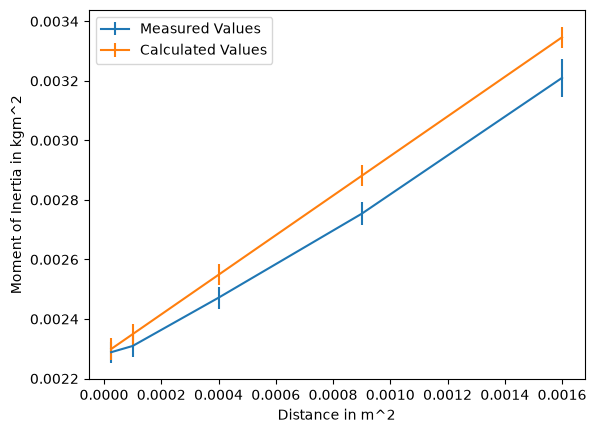

In [ ]:

Masse_komisches_Ding = ufloat(665,1) / 1000 # in kg
# Distanz zum Mittelpunkt in mm

Dist = np.array([5,10,20,30,40]) / 1000  # in mm

# 20 Schwingungen
Zeiten_komisches_Ding = [
        [46.42,46.42,46.42],
        [46.56,46.58,46.58],
        [47.73,47.72,47.78],
        [49.75,49.75,49.64],
        [52.54,52.34,53.36]
]

T_s_komisches_ding = [ufloat(np.average(x),np.sqrt(Reaktionszeit ** 2 + Fehler_des_Mittelwerts(x) ** 2)) / 20 for x in Zeiten_komisches_Ding]
print(T_s_komisches_ding)

T_s_komisches_ding = uarray_from_arrayu(T_s_komisches_ding)

J_experiment = D / (4 * np.pi** 2) * (T_s_komisches_ding ** 2 - T_1 ** 2)
J_rechnung = J_u + Masse_komisches_Ding * Dist ** 2

print(J_experiment)
print(J_rechnung)

plt.errorbar(Dist**2, unp.nominal_values(J_experiment),unp.std_devs(J_experiment), label="Measured Values")
plt.errorbar(Dist**2, unp.nominal_values(J_rechnung),unp.std_devs(J_rechnung), label="Calculated Values")
plt.xlabel("Distance in m^2")
plt.ylabel("Moment of Inertia in kgm^2")
plt.legend()

plt.savefig("Aufgabe6.svg")

[2.3209999999999997+/-0.010000000000000002
 2.3286666666666664+/-0.010005554013202422
 2.3871666666666664+/-0.010042963263455225
 2.4856666666666665+/-0.010166666666666666
 2.6373333333333333+/-0.018532254165223482]


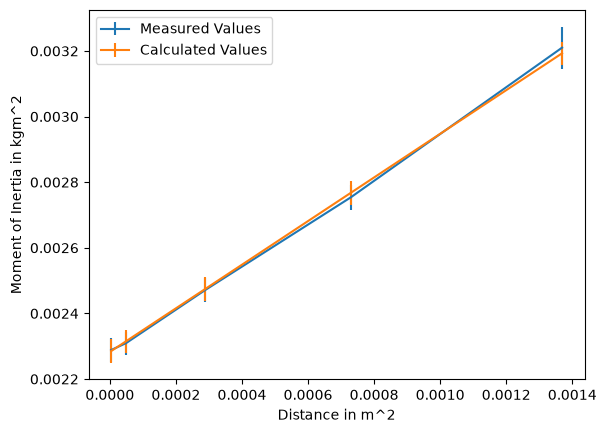

In [ ]:

Masse_komisches_Ding = ufloat(665,1) / 1000 # in kg
# Distanz zum Mittelpunkt in mm

Dist = np.array([5,10,20,30,40]) / 1000 -0.003  # in mm

# 20 Schwingungen
Zeiten_komisches_Ding = [
        [46.42,46.42,46.42],
        [46.56,46.58,46.58],
        [47.73,47.72,47.78],
        [49.75,49.75,49.64],
        [52.54,52.34,53.36]
]

T_s_komisches_ding = [ufloat(np.average(x),np.sqrt(Reaktionszeit ** 2 + Fehler_des_Mittelwerts(x) ** 2)) / 20 for x in Zeiten_komisches_Ding]
T_s_komisches_ding = uarray_from_arrayu(T_s_komisches_ding)
print(T_s_komisches_ding)

J_experiment = D / (4 * np.pi** 2) * (T_s_komisches_ding ** 2 - T_1 ** 2)
J_rechnung = J_u + Masse_komisches_Ding * Dist ** 2

plt.errorbar(Dist**2, unp.nominal_values(J_experiment),unp.std_devs(J_experiment), label="Measured Values")
plt.errorbar(Dist**2, unp.nominal_values(J_rechnung),unp.std_devs(J_rechnung), label="Calculated Values")
plt.xlabel("Distance in m^2")
plt.ylabel("Moment of Inertia in kgm^2")
plt.legend()

plt.savefig("Aufgabe6_shift.svg")

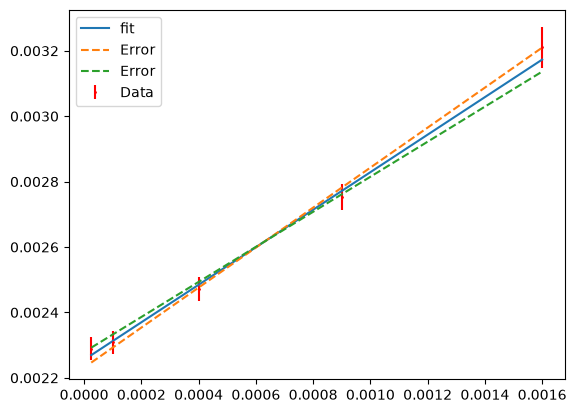

Slope: 0.57+/-0.04 Inter: 0.002255+/-0.000024


In [ ]:
# Regression vom Blauen:

fit = UCurve.ufit(Dist**2, J_experiment)
fit.draw_avg_with_errorbars(Dist**2,J_experiement)
print(fit)